# Debugging

In [18]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np
import json
import os
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.sequential as SEQUENTIAL
import nomad.stop_detection.dbscan as TADBSCAN
import nomad.stop_detection.grid_based as GRID_BASED # for oracle visits
import nomad.stop_detection.postprocessing as pp

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles

In [19]:
with open('config_2_stops.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [20]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

In [21]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
0,2024-06-01 00:00:12,1717214412,90,w-x17-y10,admiring_mestorf,-4265429.0,4393133.5,-14400
1,2024-06-01 01:30:12,1717219812,0,None,admiring_mestorf,NaN,NaN,-14400
2,2024-06-01 01:31:00,1717219860,89,r-x19-y11,admiring_mestorf,-4265414.0,4393148.5,-14400
3,2024-06-01 00:00:12,1717214412,90,w-x17-y10,affectionate_carson,-4265429.0,4393133.5,-14400
4,2024-06-01 01:30:12,1717219812,1,None,affectionate_carson,NaN,NaN,-14400
...,...,...,...,...,...,...,...,...
295,2024-06-01 01:30:12,1717219812,1,None,zealous_golick,NaN,NaN,-14400
296,2024-06-01 01:31:12,1717219872,89,r-x19-y11,zealous_golick,-4265414.0,4393148.5,-14400
297,2024-06-01 00:00:12,1717214412,90,w-x17-y10,zen_mayer,-4265429.0,4393133.5,-14400
298,2024-06-01 01:30:12,1717219812,1,None,zen_mayer,NaN,NaN,-14400


In [22]:
sparse_df = sparse_df[sparse_df['user_id'] == 'infallible_meninsky']

In [23]:
sparse_df.drop(columns=['datetime'], inplace=True)

In [24]:
diaries_df = diaries_df[diaries_df['user_id'] == 'infallible_meninsky']

In [25]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
141,2024-06-01 00:00:12,1717214412,90,w-x17-y10,infallible_meninsky,-4265429.0,4393133.5,-14400
142,2024-06-01 01:30:12,1717219812,1,None,infallible_meninsky,NaN,NaN,-14400
143,2024-06-01 01:31:12,1717219872,89,r-x19-y11,infallible_meninsky,-4265414.0,4393148.5,-14400


In [26]:
# Parameters
delta_roam = 90
dt_max=60
dur_min=5

sequential_stops = SEQUENTIAL.detect_stops(
    data=sparse_df,
    delta_roam=delta_roam,
    dt_max=dt_max,
    dur_min=dur_min,
    method='centroid',
    complete_output=False,
    traj_cols={'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}
)

In [27]:
sequential_stops

,cluster,x,y,timestamp,duration,user_id
0,0,-4.265412e+06,4.393139e+06,1717214402,177,infallible_meninsky


In [ ]:
labels = SEQUENTIAL.detect_stops_labels(
    data=sparse_df,
    delta_roam=delta_roam,
    dt_max=dt_max, 
    dur_min=dur_min,
    method='sliding',
    traj_cols={'x': 'x', 'y': 'y', 'timestamp': 'timestamp'}
)

sparse_df['cluster'] = labels

In [29]:
sparse_df["location"] = visits.point_in_polygon(
    data=sparse_df, 
    poi_table=poi_table, 
    data_crs='EPSG:3857',
    max_distance=10, 
    location_id='location', 
    method='majority',
    x='x', 
    y='y'
)

In [30]:
sparse_df

,x,y,timestamp,user_id,ha,tz_offset,cluster,location
1248,-4.265444e+06,4.393129e+06,1717214402,infallible_meninsky,15.0,-14400,0,r-x19-y11
1249,-4.265412e+06,4.393139e+06,1717215241,infallible_meninsky,15.0,-14400,0,r-x19-y11
1250,-4.265429e+06,4.393129e+06,1717215600,infallible_meninsky,15.0,-14400,0,r-x19-y11
1251,-4.265440e+06,4.393133e+06,1717216157,infallible_meninsky,15.0,-14400,0,r-x19-y11
1252,-4.265438e+06,4.393124e+06,1717216505,infallible_meninsky,15.0,-14400,0,r-x19-y11
1253,-4.265447e+06,4.393137e+06,1717216941,infallible_meninsky,15.0,-14400,0,r-x19-y11
1254,-4.265452e+06,4.393127e+06,1717217611,infallible_meninsky,15.0,-14400,0,r-x19-y11
1255,-4.265458e+06,4.393128e+06,1717217774,infallible_meninsky,15.0,-14400,0,r-x19-y11
1256,-4.265443e+06,4.393125e+06,1717218407,infallible_meninsky,15.0,-14400,0,r-x19-y11
1257,-4.265441e+06,4.393122e+06,1717218950,infallible_meninsky,15.0,-14400,0,r-x19-y11


In [31]:
summarize_stops_with_loc = partial(
    utils.summarize_stop,
    x='x',
    y='y',
    keep_col_names=False,
    passthrough_cols=['location'],
    complete_output=False)

stops = sparse_df[sparse_df.cluster!=-1].groupby('cluster', as_index=False).apply(
            summarize_stops_with_loc, include_groups=False)

In [32]:
stops

,cluster,x,y,start_timestamp,duration,location
0,0,-4.265412e+06,4.393139e+06,1717214402,177,r-x19-y11


In [33]:
diaries_df

,datetime,timestamp,duration,location,user_id,x,y,tz_offset
141,2024-06-01 00:00:12,1717214412,90,w-x17-y10,infallible_meninsky,-4265429.0,4393133.5,-14400
142,2024-06-01 01:30:12,1717219812,1,None,infallible_meninsky,NaN,NaN,-14400
143,2024-06-01 01:31:12,1717219872,89,r-x19-y11,infallible_meninsky,-4265414.0,4393148.5,-14400


In [34]:
metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=diaries_df,
            user_id='infallible_meninsky',
            algorithm='sequential',
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )

/Users/carolinechen/Desktop/cs/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'timestamp' specified for 'timestamp' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")
/Users/carolinechen/Desktop/cs/nomad/nomad/io/base.py:129: UserWarning: Trajectory column 'timestamp' specified for 'timestamp' not found in DataFrame.
  warnings.warn(f"Trajectory column '{value}' specified for '{key}' not found in DataFrame.")


In [35]:
metrics

{'precision': np.float64(0.480225988700565),
 'recall': np.float64(0.4722222222222222),
 'f1': np.float64(0.4761904761904762),
 'missed_fraction': 0.0,
 'merged_fraction': np.float64(0.5),
 'split_fraction': np.float64(0.0),
 'user_id': 'infallible_meninsky',
 'algorithm': 'sequential'}

In [36]:
labels

1248    0
1249    0
1250    0
1251    0
1252    0
1253    0
1254    0
1255    0
1256    0
1257    0
1258    0
1259    0
1260    0
1261    0
1262    0
1263    0
1264    0
1265    0
1266    0
1267    0
1268    0
1269    0
1270    0
Name: cluster, dtype: int64

[]

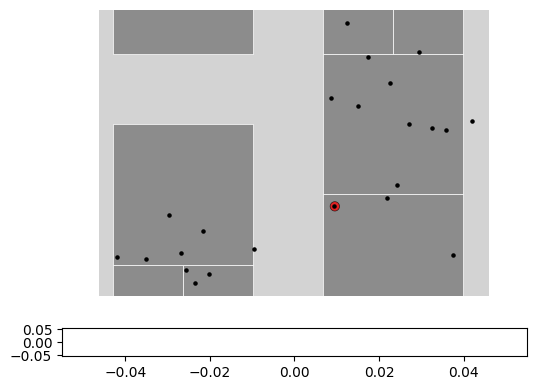

In [37]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(sequential_stops, ax=ax_map, radius=1, color='red', cmap='inferno_r', base_geometry=poi_table, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(sparse_df, ax=ax_map, s=5, color='black')

plt.plot()